# Zadanie 1: Udary - Klasyfikacja SVM z metodami balansowania danych

Cel: Zbudowanie modelu SVM do przewidywania wystąpienia udaru.

Metody balansowania:
- **Bez balansowania** (baseline)
- **Over-sampling:** RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE
- **Under-sampling:** RandomUnderSampler, ClusterCentroids, NearMiss (v1,v2,v3), TomekLinks
- **Kombinacja:** SMOTEENN, SMOTETomek
- **class_weight:** class_weight='balanced' w SVM


## Import bibliotek

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import recall_score, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Over-sampling
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE

# Under-sampling
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, NearMiss, TomekLinks

# Kombinacja
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

## Wczytanie i eksploracja danych

In [74]:
df = pd.read_csv('udar.csv')
print('Wymiary zbioru:', df.shape)
udar_test = pd.read_csv('udar_test.csv')
print('Wymiary zbioru testowego:', udar_test.shape)

df.head()

Wymiary zbioru: (42400, 12)
Wymiary zbioru testowego: (1000, 11)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,57111,Female,9.0,0,0,No,children,Rural,130.05,18.8,NaN,0
1,2232,Male,57.0,1,0,Yes,Private,Urban,87.98,30.7,never smoked,0
2,18224,Female,10.0,0,0,No,children,Rural,79.42,19.1,NaN,0
3,21683,Male,24.0,0,0,Yes,Private,Urban,77.07,32.9,NaN,0
4,26553,Female,62.0,0,0,Yes,Private,Urban,94.22,17.4,never smoked,0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42400 entries, 0 to 42399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 42400 non-null  int64  
 1   gender             42400 non-null  str    
 2   age                42400 non-null  float64
 3   hypertension       42400 non-null  int64  
 4   heart_disease      42400 non-null  int64  
 5   ever_married       42400 non-null  str    
 6   work_type          42400 non-null  str    
 7   Residence_type     42400 non-null  str    
 8   avg_glucose_level  42400 non-null  float64
 9   bmi                40971 non-null  float64
 10  smoking_status     29394 non-null  str    
 11  stroke             42400 non-null  int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 3.9 MB


In [76]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,42400.000000,42400.000000,42400.000000,42400.000000,42400.000000,40971.000000,42400.000000
mean,36329.083160,42.205254,0.093420,0.047642,104.499226,28.592033,0.018137
std,21067.121638,22.538894,0.291023,0.213009,43.135420,7.773218,0.133448
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18046.250000,24.000000,0.000000,0.000000,77.530000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.590000,27.700000,0.000000
75%,54520.250000,60.000000,0.000000,0.000000,112.090000,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


Rozkład zmiennej stroke:
stroke
0    41631
1      769
Name: count, dtype: int64

Procent udarów: 1.81%


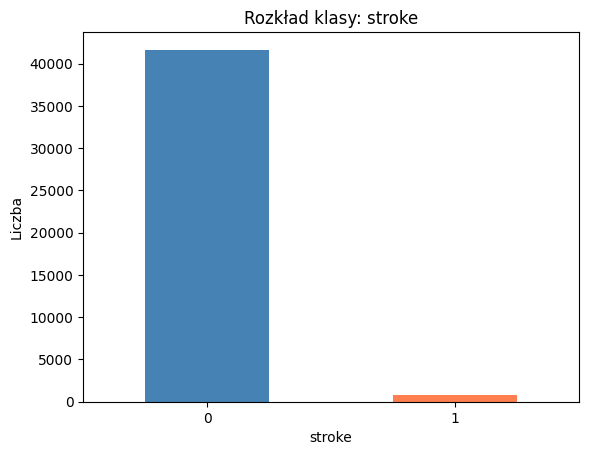

In [77]:
# Rozkład klasy docelowej
print('Rozkład zmiennej stroke:')
print(df['stroke'].value_counts())
print(f'\nProcent udarów: {df["stroke"].mean()*100:.2f}%')

df['stroke'].value_counts().plot(kind='bar', color=['steelblue','coral'])
plt.title('Rozkład klasy: stroke')
plt.xlabel('stroke')
plt.ylabel('Liczba')
plt.xticks(rotation=0)
plt.show()

In [78]:
# Brakujące wartości
print('Brakujące wartości:')
print(df.isnull().sum())

Brakujące wartości:
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1429
smoking_status       13006
stroke                   0
dtype: int64


In [79]:
udar_test.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                   33
smoking_status       286
dtype: int64

## Przygotowanie danych

In [80]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [81]:
df_train = df.copy()

# Usunięcie kolumny id
df_train = df_train.drop(columns='id')
udar_test = udar_test.drop(columns='id')

# Podział na kolumny kategoryczne i numeryczne
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']
num_cols = ['avg_glucose_level', 'bmi']


print(f'Kolumny kategoryczne: {cat_cols}')
print(f'Kolumny numeryczne: {num_cols}')

Kolumny kategoryczne: ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']
Kolumny numeryczne: ['avg_glucose_level', 'bmi']


In [82]:
# Uzupełnianie braków
median_val_bmi = df_train['bmi'].median()
df_train['bmi'] = df_train['bmi'].fillna(median_val_bmi)
print(f"\nUzupełniono bmi medianą: {median_val_bmi}")

new_category = 'noinfo'
df_train['smoking_status'] = df_train['smoking_status'].fillna(new_category)

print('\nBrakujące wartości po uzupełnieniu:')
print(df_train.isnull().sum().sum())


Uzupełniono bmi medianą: 27.7

Brakujące wartości po uzupełnieniu:
0


In [83]:
# Uzupełnianie braków udar_test
median_val_bmi_udar = udar_test['bmi'].median()
udar_test['bmi'] = udar_test['bmi'].fillna(median_val_bmi_udar)
print(f"\nUzupełniono bmi medianą: {median_val_bmi_udar}")

udar_test['smoking_status'] = udar_test['smoking_status'].fillna(new_category)

print('\nBrakujące wartości po uzupełnieniu:')
print(udar_test.isnull().sum().sum())


Uzupełniono bmi medianą: 28.3

Brakujące wartości po uzupełnieniu:
0


In [84]:
df_train

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,9.0,0,0,No,children,Rural,130.05,18.8,noinfo,0
1,Male,57.0,1,0,Yes,Private,Urban,87.98,30.7,never smoked,0
2,Female,10.0,0,0,No,children,Rural,79.42,19.1,noinfo,0
3,Male,24.0,0,0,Yes,Private,Urban,77.07,32.9,noinfo,0
4,Female,62.0,0,0,Yes,Private,Urban,94.22,17.4,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
42395,Female,55.0,0,0,Yes,Private,Rural,87.26,27.6,never smoked,0
42396,Male,74.0,0,1,Yes,Govt_job,Rural,222.56,27.7,formerly smoked,0
42397,Male,5.0,0,0,No,children,Urban,62.43,17.5,noinfo,0
42398,Female,27.0,0,0,No,Private,Urban,103.23,36.3,noinfo,0


In [85]:
udar_test

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,3.0,0,0,No,children,Rural,97.87,24.5,noinfo
1,Female,53.0,0,0,Yes,Self-employed,Urban,101.30,33.1,never smoked
2,Female,32.0,0,0,No,Self-employed,Rural,175.73,42.4,formerly smoked
3,Female,50.0,1,0,Yes,Private,Rural,88.29,28.5,never smoked
4,Female,29.0,0,0,No,Govt_job,Urban,72.51,47.7,noinfo
...,...,...,...,...,...,...,...,...,...,...
995,Male,29.0,0,0,No,Private,Rural,90.52,26.2,never smoked
996,Male,45.0,0,0,Yes,Private,Urban,76.72,29.1,noinfo
997,Female,61.0,0,0,Yes,Private,Urban,93.04,24.6,formerly smoked
998,Female,49.0,0,0,Yes,Private,Urban,87.80,25.6,never smoked


In [86]:
df_encoded = df_train.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'Zakodowano {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Zakodowano gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Zakodowano hypertension: {'0': np.int64(0), '1': np.int64(1)}
Zakodowano heart_disease: {'0': np.int64(0), '1': np.int64(1)}
Zakodowano ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
Zakodowano work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Zakodowano Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
Zakodowano smoking_status: {'formerly smoked': np.int64(0), 'never smoked': np.int64(1), 'noinfo': np.int64(2), 'smokes': np.int64(3)}
Zakodowano stroke: {'0': np.int64(0), '1': np.int64(1)}


In [87]:
udar_encoded = udar_test.copy()
label_encoders_udar = {}
for col in cat_cols:
    if col == 'stroke': 
        continue
    le_udar = LabelEncoder()
    udar_encoded[col] = le_udar.fit_transform(udar_encoded[col].astype(str))
    label_encoders_udar[col] = le_udar
    print(f'Zakodowano {col}: {dict(zip(le_udar.classes_, le_udar.transform(le_udar.classes_)))}')

Zakodowano gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Zakodowano hypertension: {'0': np.int64(0), '1': np.int64(1)}
Zakodowano heart_disease: {'0': np.int64(0), '1': np.int64(1)}
Zakodowano ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
Zakodowano work_type: {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Zakodowano Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
Zakodowano smoking_status: {'formerly smoked': np.int64(0), 'never smoked': np.int64(1), 'noinfo': np.int64(2), 'smokes': np.int64(3)}


In [88]:
cols_to_dummy = ['gender', 'work_type', 'smoking_status']

#Tworzymy zmienne fikcyjne (One-Hot Encoding)
df_encoded = pd.get_dummies(df_encoded, columns=cols_to_dummy)

dummy_cols = [col for col in df_encoded.columns if any(orig in col for orig in cols_to_dummy)]
df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(int)

# Sprawdzenie wymiarów po rozszerzeniu macierzy
print(f'Wymiary zbioru po utworzeniu dummy variables: {df_encoded.shape}')

Wymiary zbioru po utworzeniu dummy variables: (42400, 20)


In [89]:
udar_encoded = pd.get_dummies(udar_encoded, columns=cols_to_dummy)

dummy_cols_udar = [col for col in udar_encoded.columns if any(orig in col for orig in cols_to_dummy)]
udar_encoded[dummy_cols_udar] = udar_encoded[dummy_cols_udar].astype(int)

print(f'Wymiary zbioru po utworzeniu dummy variables: {udar_encoded.shape}')

Wymiary zbioru po utworzeniu dummy variables: (1000, 19)


In [90]:
df_encoded

,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,gender_0,gender_1,gender_2,work_type_0,work_type_1,work_type_2,work_type_3,work_type_4,smoking_status_0,smoking_status_1,smoking_status_2,smoking_status_3
0,9.0,0,0,0,0,130.05,18.8,0,1,0,0,0,0,0,0,1,0,0,1,0
1,57.0,1,0,1,1,87.98,30.7,0,0,1,0,0,0,1,0,0,0,1,0,0
2,10.0,0,0,0,0,79.42,19.1,0,1,0,0,0,0,0,0,1,0,0,1,0
3,24.0,0,0,1,1,77.07,32.9,0,0,1,0,0,0,1,0,0,0,0,1,0
4,62.0,0,0,1,1,94.22,17.4,0,1,0,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42395,55.0,0,0,1,0,87.26,27.6,0,1,0,0,0,0,1,0,0,0,1,0,0
42396,74.0,0,1,1,0,222.56,27.7,0,0,1,0,1,0,0,0,0,1,0,0,0
42397,5.0,0,0,0,1,62.43,17.5,0,0,1,0,0,0,0,0,1,0,0,1,0
42398,27.0,0,0,0,1,103.23,36.3,0,1,0,0,0,0,1,0,0,0,0,1,0


In [91]:
# Podział na cechy i zmienną docelową
X = df_encoded.drop(columns='stroke')
y = df_encoded['stroke']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Zbiór treningowy: {X_train_scaled.shape}, Testowy: {X_test_scaled.shape}')
print(f'Rozkład w zbiorze treningowym: {pd.Series(y_train).value_counts().to_dict()}')

Zbiór treningowy: (33920, 19), Testowy: (8480, 19)
Rozkład w zbiorze treningowym: {0: 33305, 1: 615}


## Modele SVM z różnymi metodami balansowania

In [92]:
# Pomocnicza funkcja do treningu i oceny modelu SVM
def train_evaluate_svm(X_tr, y_tr, X_te, y_te, label='', kernel = 'rbf', C=1.0, class_weight=None):
    clf = SVC(kernel=kernel, C=C, class_weight=class_weight, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    recall = recall_score(y_te, y_pred)
    accuracy = accuracy_score(y_te, y_pred)
    print(f'{label}: Recall: {recall:.4f}, Accuracy: {accuracy:.4f}')
    return clf, recall, accuracy, y_pred

results = {}

### 1 Baseline, bez balansowania

In [93]:
clf_base, r, a, _ = train_evaluate_svm(X_train_scaled, y_train, X_test_scaled, y_test, label='Bez balansowania (linear)', kernel='linear')
results['Bez balansowania (linear)'] = {'recall': r, 'accuracy': a, 'model': clf_base}

clf_base_rbf, r, a, _ = train_evaluate_svm(X_train_scaled, y_train, X_test_scaled, y_test, label='Bez balansowania (rbf)', kernel='rbf')
results['Bez balansowania (rbf)'] = {'recall': r, 'accuracy': a, 'model': clf_base_rbf}

Bez balansowania (linear): Recall: 0.0000, Accuracy: 0.9818
Bez balansowania (rbf): Recall: 0.0000, Accuracy: 0.9818


### 2 class_weight='balanced' w SVM

In [94]:
for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_train_scaled, y_train, X_test_scaled, y_test, label=f'class_weight=balanced ({kernel})', kernel=kernel, class_weight='balanced')
    results[f'class_weight=balanced ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

class_weight=balanced (linear): Recall: 0.8701, Accuracy: 0.7307
class_weight=balanced (rbf): Recall: 0.6883, Accuracy: 0.7801


### 3 Over-sampling: RandomOverSampler

In [95]:
# RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train_scaled, y_train)
print(f'Po RandomOverSampler: {pd.Series(y_ros).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_ros, y_ros, X_test_scaled, y_test, label=f'RandomOverSampler ({kernel})', kernel=kernel)
    results[f'RandomOverSampler ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po RandomOverSampler: {0: 33305, 1: 33305}
RandomOverSampler (linear): Recall: 0.8701, Accuracy: 0.7304
RandomOverSampler (rbf): Recall: 0.6429, Accuracy: 0.7890


### 4 Over-sampling: SMOTE

In [96]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTE: {pd.Series(y_smote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(
        X_smote, y_smote, X_test_scaled, y_test,
        label=f'SMOTE ({kernel})', kernel=kernel
    )
    results[f'SMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SMOTE: {0: 33305, 1: 33305}
SMOTE (linear): Recall: 0.8701, Accuracy: 0.7303
SMOTE (rbf): Recall: 0.5584, Accuracy: 0.8121


### 5 Over-sampling: ADASYN

In [97]:
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X_train_scaled, y_train)
print(f'Po ADASYN: {pd.Series(y_adasyn).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_adasyn, y_adasyn, X_test_scaled, y_test, label=f'ADASYN ({kernel})', kernel=kernel)
    results[f'ADASYN ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}


Po ADASYN: {1: 33394, 0: 33305}
ADASYN (linear): Recall: 0.8701, Accuracy: 0.7221
ADASYN (rbf): Recall: 0.5714, Accuracy: 0.8061


### 6 Over-sampling: BorderlineSMOTE

In [98]:
bsmote = BorderlineSMOTE(random_state=42)
X_bsmote, y_bsmote = bsmote.fit_resample(X_train_scaled, y_train)
print(f'Po BorderlineSMOTE: {pd.Series(y_bsmote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
        clf_, r, a, _ = train_evaluate_svm(X_bsmote, y_bsmote, X_test_scaled, y_test, label=f'BorderlineSMOTE ({kernel})', kernel=kernel)
        results[f'BorderlineSMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}


Po BorderlineSMOTE: {0: 33305, 1: 33305}
BorderlineSMOTE (linear): Recall: 0.7597, Accuracy: 0.7958
BorderlineSMOTE (rbf): Recall: 0.4286, Accuracy: 0.8803


### 7 Over-sampling: SVMSMOTE

In [99]:
svmsmote = SVMSMOTE(random_state=42)
X_svmsmote, y_svmsmote = svmsmote.fit_resample(X_train_scaled, y_train)
print(f'Po SVMSMOTE: {pd.Series(y_svmsmote).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_svmsmote, y_svmsmote, X_test_scaled, y_test, label=f'SVMSMOTE ({kernel})', kernel=kernel)
    results[f'SVMSMOTE ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SVMSMOTE: {0: 33305, 1: 18593}
SVMSMOTE (linear): Recall: 0.7143, Accuracy: 0.8443
SVMSMOTE (rbf): Recall: 0.3117, Accuracy: 0.9002


### 8 Under-sampling: RandomUnderSampler

In [100]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train)
print(f'Po RandomUnderSampler: {pd.Series(y_rus).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_rus, y_rus, X_test_scaled, y_test, label=f'RandomUnderSampler ({kernel})', kernel=kernel)
    results[f'RandomUnderSampler ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po RandomUnderSampler: {0: 615, 1: 615}
RandomUnderSampler (linear): Recall: 0.8636, Accuracy: 0.7353
RandomUnderSampler (rbf): Recall: 0.8636, Accuracy: 0.7055


### 9 Under-sampling: ClusterCentroids

In [101]:
cc = ClusterCentroids(random_state=42)
X_cc, y_cc = cc.fit_resample(X_train_scaled, y_train)
print(f'Po ClusterCentroids: {pd.Series(y_cc).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_cc, y_cc, X_test_scaled, y_test, label=f'ClusterCentroids ({kernel})', kernel=kernel)
    results[f'ClusterCentroids ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}


Po ClusterCentroids: {0: 615, 1: 615}
ClusterCentroids (linear): Recall: 0.7987, Accuracy: 0.7284
ClusterCentroids (rbf): Recall: 0.7468, Accuracy: 0.7314


### 10 Under-sampling: NearMiss (wersje 1, 2, 3)

In [102]:
for version in [1, 2, 3]:
    nm = NearMiss(version=version)
    X_nm, y_nm = nm.fit_resample(X_train_scaled, y_train)
    print(f'Po NearMiss - {version}: {pd.Series(y_nm).value_counts().to_dict()}')

    for kernel in ['linear', 'rbf']:
        clf_, r, a, _ = train_evaluate_svm(X_nm, y_nm, X_test_scaled, y_test, label=f'NearMiss-{version} ({kernel})', kernel=kernel)
        results[f'NearMiss-{version} ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po NearMiss - 1: {0: 615, 1: 615}
NearMiss-1 (linear): Recall: 0.6883, Accuracy: 0.3254
NearMiss-1 (rbf): Recall: 0.7792, Accuracy: 0.2383
Po NearMiss - 2: {0: 615, 1: 615}
NearMiss-2 (linear): Recall: 0.8506, Accuracy: 0.2185
NearMiss-2 (rbf): Recall: 0.9416, Accuracy: 0.1070
Po NearMiss - 3: {0: 615, 1: 615}
NearMiss-3 (linear): Recall: 0.6883, Accuracy: 0.5287
NearMiss-3 (rbf): Recall: 0.5649, Accuracy: 0.5301


### 11 Under-sampling: TomekLinks

In [103]:
tl = TomekLinks()
X_tl, y_tl = tl.fit_resample(X_train_scaled, y_train)
print(f'Po TomekLinks: {pd.Series(y_tl).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_tl, y_tl, X_test_scaled, y_test, label=f'TomekLinks ({kernel})', kernel=kernel)
    results[f'TomekLinks ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po TomekLinks: {0: 32980, 1: 615}
TomekLinks (linear): Recall: 0.0000, Accuracy: 0.9818
TomekLinks (rbf): Recall: 0.0000, Accuracy: 0.9818


### 12 Kombinacja: SMOTEENN

In [104]:
smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTEENN: {pd.Series(y_smoteenn).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_smoteenn, y_smoteenn, X_test_scaled, y_test, label=f'SMOTEENN ({kernel})', kernel=kernel)
    results[f'SMOTEENN ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}


Po SMOTEENN: {1: 31670, 0: 29268}
SMOTEENN (linear): Recall: 0.8831, Accuracy: 0.7138
SMOTEENN (rbf): Recall: 0.6104, Accuracy: 0.7920


### 13 Kombinacja: SMOTETomek

In [105]:
smotetomek = SMOTETomek(random_state=42)
X_smotetomek, y_smotetomek = smotetomek.fit_resample(X_train_scaled, y_train)
print(f'Po SMOTETomek: {pd.Series(y_smotetomek).value_counts().to_dict()}')

for kernel in ['linear', 'rbf']:
    clf_, r, a, _ = train_evaluate_svm(X_smotetomek, y_smotetomek, X_test_scaled, y_test, label=f'SMOTETomek ({kernel})', kernel=kernel)
    results[f'SMOTETomek ({kernel})'] = {'recall': r, 'accuracy': a, 'model': clf_}

Po SMOTETomek: {0: 33091, 1: 33091}
SMOTETomek (linear): Recall: 0.8701, Accuracy: 0.7304
SMOTETomek (rbf): Recall: 0.5649, Accuracy: 0.8118


## Podsumowanie wyników

In [113]:
collected_data = []

for method, value in results.items():
    if 'model' in value:
        data = {
            'Metoda': method,
            'Recall': value['recall'],
            'Accuracy': value['accuracy']
        }
        collected_data.append(data)


results_df = pd.DataFrame(collected_data)
results_df = results_df.sort_values(by='Recall', ascending=False)

print('\n RANKING MODELI wg Recall')
print(results_df.to_string(index=False))


 RANKING MODELI wg Recall
                        Metoda   Recall  Accuracy
              NearMiss-2 (rbf) 0.941558  0.106958
             SMOTEENN (linear) 0.883117  0.713797
               ADASYN (linear) 0.870130  0.722052
                SMOTE (linear) 0.870130  0.730307
    RandomOverSampler (linear) 0.870130  0.730425
class_weight=balanced (linear) 0.870130  0.730660
           SMOTETomek (linear) 0.870130  0.730425
   RandomUnderSampler (linear) 0.863636  0.735259
      RandomUnderSampler (rbf) 0.863636  0.705542
           NearMiss-2 (linear) 0.850649  0.218514
     ClusterCentroids (linear) 0.798701  0.728420
              NearMiss-1 (rbf) 0.779221  0.238325
      BorderlineSMOTE (linear) 0.759740  0.795755
        ClusterCentroids (rbf) 0.746753  0.731368
             SVMSMOTE (linear) 0.714286  0.844340
           NearMiss-1 (linear) 0.688312  0.325354
           NearMiss-3 (linear) 0.688312  0.528656
   class_weight=balanced (rbf) 0.688312  0.780071
       RandomOverSample

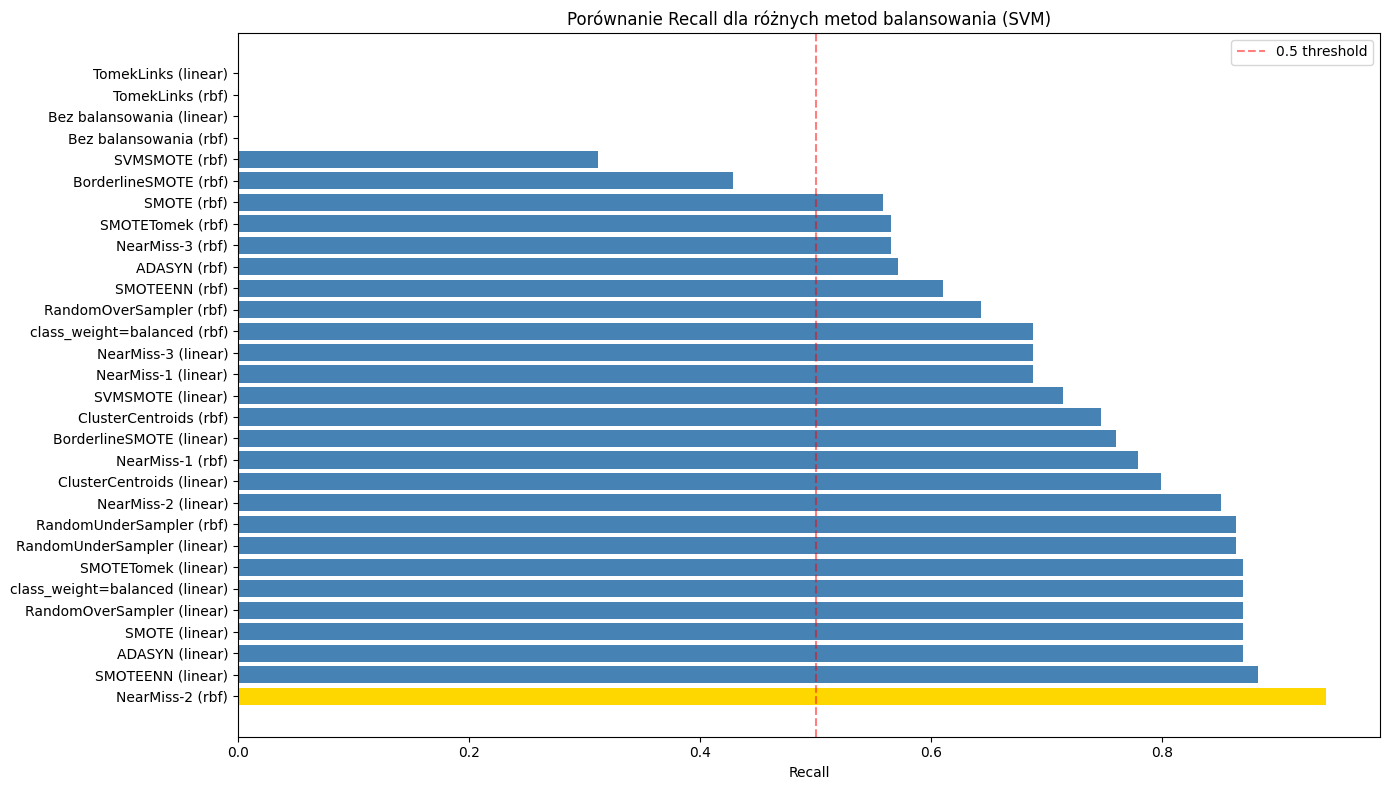


Najlepszy model: NearMiss-2 (rbf) (Recall = 0.9416)


In [114]:
# Wizualizacja recall
plt.figure(figsize=(14, 8))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Metoda'], results_df['Recall'], color=colors)
plt.xlabel('Recall')
plt.title('Porównanie Recall dla różnych metod balansowania (SVM)')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
plt.legend()
plt.tight_layout()
plt.show()

best_method = results_df.iloc[0]['Metoda']
best_recall = results_df.iloc[0]['Recall']
print(f'\nNajlepszy model: {best_method} (Recall = {best_recall:.4f})')

## Najlepszy model - szczegółowa analiza

Mimo, że model NearMiss-2 (rbf) ma najwiekszy recall, to ma zbyt niskie accuracy aby móc go używać, trzeba to zmienić

In [115]:
# Filtrowanie i sortowanie
best_models_df = results_df[results_df['Accuracy'] > 0.50].sort_values(by=['Recall', 'Accuracy'], ascending=False)

# Wybranie najlepszego
best_method_name = best_models_df.iloc[0]['Metoda']
best_score = best_models_df.iloc[0]['Recall']
print(f"Najlepszy model wg rankingu: {best_method_name} (Recall: {best_score:.4f})")


Najlepszy model wg rankingu: SMOTEENN (linear) (Recall: 0.8831)


## Predykcja na zbiorze testowym

In [116]:
df_test_proc = udar_encoded.copy()

# Wyrównanie kolumn z treningiem
test_features = X.columns.tolist()
X_pred = df_test_proc[test_features]
X_pred_scaled = scaler.transform(X_pred)

print('Przygotowane dane testowe:', X_pred_scaled.shape)

Przygotowane dane testowe: (1000, 19)


In [117]:
# Predykcja
# Wyciągnięcie najlepszego modelu
best_clf = results[best_method_name]['model']
stroke_pred = best_clf.predict(X_pred_scaled)

print(f'Rozkład predykcji: {pd.Series(stroke_pred).value_counts().to_dict()}')
print(f'Procent predykowanych udarów: {stroke_pred.mean()*100:.2f}%')

Rozkład predykcji: {0: 699, 1: 301}
Procent predykowanych udarów: 30.10%


In [119]:
# Zapis wyników do pliku u.csv
u_csv = pd.DataFrame({'stroke': stroke_pred})
u_csv.to_csv('u.csv', index=False)
print('Zapisano plik u.csv')

Zapisano plik u.csv
